# Cloud Detector Training — Stage 2a: Legacy Features

Replicates the original cloud-detector training using the pre-packaged features and
labels from `assets/models/cloud-detection-training/`. This is the fastest path to
reproducing the model without needing to re-process raw PFF data.

## Pipeline
```
training-labels.zip + training-data-batch.zip
        ↓  pa-prep-cloud-legacy
feature cache Zarr  (X: N×2×32×32, label: N, split: N)
        ↓  pa-train-cloud / run_train_cloud()
cloud_detector_v2_legacy.pt  +  ClassifierBundle.json
```

## Feature differences from original
The original pipeline stored `raw-fft` as a (64, 64) zero-padded FFT.  
Here we re-compute both channels at (32, 32) to match the model's `input_spec`:
- **Channel 0**: `FFT(raw-derivative.-60)` — 60-second time derivative
- **Channel 1**: `FFT(raw-original)` — current frame

Both channels use a 2D Hann window and square-root magnitude scaling.

## W&B experiment tracking
Set `WANDB_API_KEY` in your `.env` file (see `docs/wandb.md`).  
If not set, training falls back to TensorBoard in `logs/`.

In [1]:
%load_ext autoreload
%autoreload 2

import os

# Load .env if present
from pathlib import Path

# Editable install (uv sync) makes panoseti_analysis importable — no path hacks.
from panoseti_analysis.paths import REPO_ROOT

_env_file = REPO_ROOT / ".env"
if _env_file.exists():
    for line in _env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip())
    print("Loaded .env")

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_recall_curve

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print(f"PyTorch {torch.__version__}, CUDA available: {torch.cuda.is_available()}")

Loaded .env
PyTorch 2.12.0+cu130, CUDA available: True


## §0 Configuration

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# REPO_ROOT is imported from panoseti_analysis.paths (see imports cell)
LABELS_ZIP = REPO_ROOT / "assets/models/cloud-detection-training/training-labels.zip"
DATA_ZIP = REPO_ROOT / "assets/models/cloud-detection-training/training-data-batch.zip"
BEEGFS_ROOT = Path("/mnt/beegfs/panoseti_analysis")

# Batch extraction: use local NVMe SSD to avoid BeeGFS small-file overhead.
# The training-data-batch.zip unpacks to thousands of small .npy files; BeeGFS
# (parallel FS) has high metadata overhead for many small files — use local disk.
# CACHE_ZARR stays on the shared FS so training workers on any node can read it.
LOCAL_SCRATCH = Path("/local/scratch") if Path("/local/scratch").exists() else Path("/tmp")
EXTRACT_DIR = LOCAL_SCRATCH / "panoseti_cache"

CACHE_ZARR = REPO_ROOT / "ml/cloud-detection/cache/cloud_features_legacy.zarr"
OUT_DIR = REPO_ROOT / "ml/cloud-detection/models"
RECIPE_PATH = REPO_ROOT / "recipes/ml/cloud_v1.yml"

# ── Training options ──────────────────────────────────────────────────────────
BATCH_IDS = list(range(8))  # batches 0–7 (all available in the zip)
EPOCHS = 50  # set lower (e.g., 5) for a quick smoke test
WANDB_PROJECT = "panoseti-cloud-detection"  # set to None to disable W&B

print(f"Labels zip  : {LABELS_ZIP.exists()}")
print(f"Data zip    : {DATA_ZIP.exists()}, size={DATA_ZIP.stat().st_size / 1e6:.0f}MB")
print(f"Local scratch: {LOCAL_SCRATCH}  (extraction goes here)")
print(f"Cache Zarr  : {CACHE_ZARR.exists()} (will build if missing)")
print(f"Output dir  : {OUT_DIR}")
print(f"Recipe      : {RECIPE_PATH.exists()}")

Labels zip  : True
Data zip    : True, size=599MB
Local scratch: /tmp  (extraction goes here)
Cache Zarr  : True (will build if missing)
Output dir  : /home/nico/panoseti_analysis/ml/cloud-detection/models
Recipe      : True


## §1 Build Feature Cache

Extracts the zips, loads numpy features + label CSVs, and writes a feature-cache Zarr.

In [5]:
import logging

from panoseti_analysis.adapters.cloud.prep_legacy import build_legacy_feature_cache

logging.basicConfig(level=logging.INFO, format="%(message)s")

if CACHE_ZARR.exists():
    print(f"Cache already exists: {CACHE_ZARR}")
    print("Delete it to force rebuild.")
else:
    print(f"Building feature cache from {len(BATCH_IDS)} batches…")
    build_legacy_feature_cache(
        labels_zip=LABELS_ZIP,
        data_zip=DATA_ZIP,
        extract_dir=EXTRACT_DIR,
        out_path=CACHE_ZARR,
        batch_ids=BATCH_IDS,
        skip_unsure=True,
        recipe_path=RECIPE_PATH,
    )
    print("Done.")

Cache already exists: /home/nico/panoseti_analysis/ml/cloud-detection/cache/cloud_features_legacy.zarr
Delete it to force rebuild.


## §2 Inspect Dataset

In [6]:
ds = xr.open_zarr(CACHE_ZARR, consolidated=False)
X_all = ds["X"].values.astype(np.float32)  # (N, 2, 32, 32)
y_all = ds["label"].values.astype(np.int64)  # (N,)
split = ds["split"].values  # (N,) str
batch_id = ds["batch_id"].values

N = len(y_all)
print(f"Dataset: {N:,} samples, {X_all.shape[1]} channels, {X_all.shape[2]}×{X_all.shape[3]} px")
print(f"  clear (0): {(y_all == 0).sum():,}  cloudy (1): {(y_all == 1).sum():,}")
print(
    f"  train: {(split == 'train').sum():,}  val: {(split == 'val').sum():,}  test: {(split == 'test').sum():,}"
)
print(f"  batch IDs: {sorted(set(batch_id.tolist()))}")

Dataset: 8,799 samples, 2 channels, 32×32 px
  clear (0): 3,955  cloudy (1): 4,844
  train: 6,601  val: 879  test: 1,319
  batch IDs: [0, 1, 2, 3, 4, 5, 6, 7]


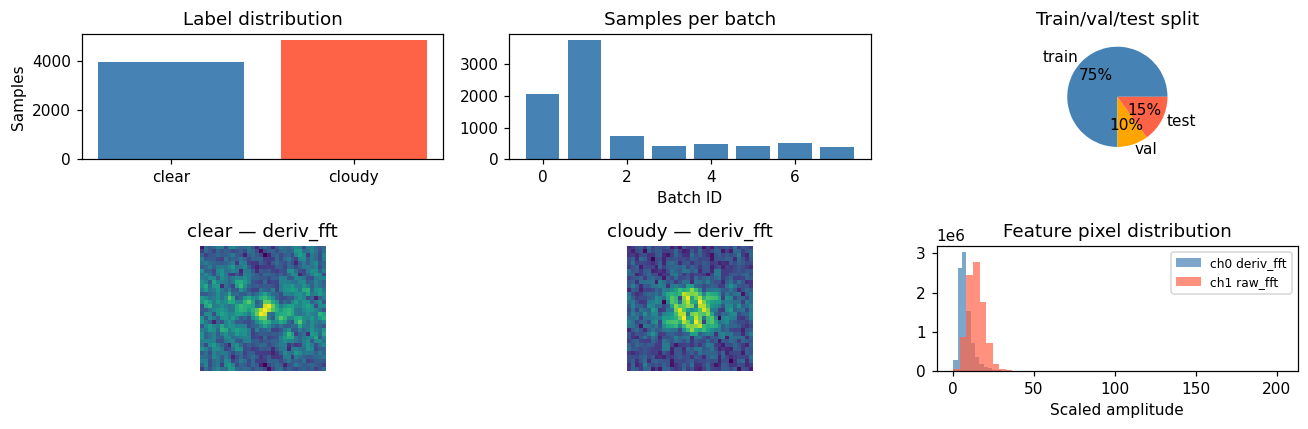

In [7]:
# ── Dataset visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 4))

# Class distribution
ax = axes[0, 0]
ax.bar(["clear", "cloudy"], [(y_all == 0).sum(), (y_all == 1).sum()], color=["steelblue", "tomato"])
ax.set_title("Label distribution")
ax.set_ylabel("Samples")

# Per-batch counts
ax = axes[0, 1]
batches = sorted(set(batch_id.tolist()))
counts = [(batch_id == b).sum() for b in batches]
ax.bar(batches, counts, color="steelblue")
ax.set_title("Samples per batch")
ax.set_xlabel("Batch ID")

# Split pie
ax = axes[0, 2]
sizes = [(split == s).sum() for s in ["train", "val", "test"]]
ax.pie(
    sizes,
    labels=["train", "val", "test"],
    autopct="%1.0f%%",
    colors=["steelblue", "orange", "tomato"],
)
ax.set_title("Train/val/test split")

# Sample images per class
for col, (cls, name) in enumerate([(0, "clear"), (1, "cloudy")]):
    idx = np.where(y_all == cls)[0][0]
    ax = axes[1, col]
    ax.imshow(X_all[idx, 0], cmap="viridis", interpolation="nearest")
    ax.set_title(f"{name} — deriv_fft")
    ax.axis("off")

ax = axes[1, 2]
ax.hist(X_all[:, 0].ravel(), bins=50, color="steelblue", alpha=0.7, label="ch0 deriv_fft")
ax.hist(X_all[:, 1].ravel(), bins=50, color="tomato", alpha=0.7, label="ch1 raw_fft")
ax.set_title("Feature pixel distribution")
ax.set_xlabel("Scaled amplitude")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
# import torch.nn as nn

# class CloudDetectionV2(nn.Module):

#     input_shape = (2, 32, 32)

#     def __init__(self) -> None:
#         super().__init__()

#         # Lift legacy input to the right dimensions
#         self.conv_lift = nn.LazyConv2d(
#             out_channels=3,
#             kernel_size=3,
#             padding=1,
#         )

#         # load convextmodel and freeze weights
#         self.convnext = convnext_tiny(
#             weights=ConvNeXt_Tiny_Weights
#         )
#         for p in self.convnext.parameters():
#             p.requires_grad = False

#         # Train new classifer heads
#         self.convnext.classifier[2] = nn.Linear(768, 128, bias=True)
#         self.fc = nn.Sequential(
#             nn.LayerNorm(128),
#             nn.GELU(),
#             nn.Linear(128, 2)
#         )

#     def forward(self, x: torch.Tensor):
#         out = self.conv_lift(x)
#         out = self.convnext(out)
#         out = self.fc(out)
#         return out

# from panoseti_analysis.algorithms.cloud_detector import CloudDetection
# cd2 = CloudDetectionV2()
# cd1 = CloudDetection()

# x0 = torch.Tensor(X_all[0:2])
# cd2(x0), cd1(x0)
# # x0.shape

## §3 Train

Uses `run_train_cloud()` from the Ray adapter in **attach mode** — connects to the
running RAL cluster (digilab-receiver as head, `accelerator_type:G` GPU workers).

The cell below reconnects Ray with a `runtime_env` that ships the `panoseti_analysis`
source tree to each worker, solving the `No module named 'panoseti_analysis'` error
on remote nodes.

For full training on all 8 batches (8,804 samples), expect ~5–15 min on GPU.

> **New:** to generate fresh L1 stores for relabelling with your own calibration recipe,
> use `run_pipeline(obs_dir, out_dir, calib_recipe=RECIPE_PATH)` instead of Nextflow.
> The recipe hash is stamped into every L1 attrs block — use
> `ds.attrs["calibration"]["resolution"]["source_hash"]` to verify which recipe produced a store.

In [9]:
import ray

from panoseti_analysis.adapters.ray.train_cloud import run_train_cloud

if WANDB_PROJECT and os.environ.get("WANDB_API_KEY"):
    print(f"W&B tracking enabled: project='{WANDB_PROJECT}'")
else:
    print("W&B not configured — using TensorBoard (see logs/).")
    os.environ["WANDB_MODE"] = "disabled"

# Reconnect Ray with a runtime_env that ships panoseti_analysis source to remote workers.
# Required because train workers run on a separate node (digilab-transmit) that doesn't
# have panoseti_analysis installed in its Python path.
# Disconnect first so the new runtime_env takes effect (safe: only drops local connection,
# the RAL cluster keeps running).
if ray.is_initialized():
    ray.shutdown()

_training_runtime_env = {
    "working_dir": str(REPO_ROOT),
    "env_vars": {"PYTHONPATH": "src"},
    "excludes": [
        ".venv/",
        ".git/",
        "*.zarr/",
        "uv.lock",
        ".claude/",
        "assets/models/cloud-detection-training/",
        "ml/*/cache/",
        "ml/*/models/",
        "ml/*/data/",
        "pypff/example/",
        "grpc/src/panoseti_grpc/daq_data/simulated_data_dir/",
        "grpc/scripts/daq_data/simulated_data_dir/",
    ],
}
if os.environ.get("WANDB_API_KEY"):
    _training_runtime_env["env_vars"]["WANDB_API_KEY"] = os.environ["WANDB_API_KEY"]

ray.init(address="auto", runtime_env=_training_runtime_env, ignore_reinit_error=True)
print(f"Ray connected: {ray.cluster_resources()}")

OUT_DIR.mkdir(parents=True, exist_ok=True)

pt_path, json_path, prov_path = run_train_cloud(
    feature_cache=CACHE_ZARR,
    out_dir=OUT_DIR,
    recipe_path=RECIPE_PATH,
    launcher="attach",
    local_cache_dir=None,
    wandb_project=WANDB_PROJECT,
    epochs=EPOCHS,
    lineage_out=None,
)
print(f"Model saved: {pt_path}")
print(f"Bundle:      {json_path}")

2026-06-03 12:07:10,914	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.1.14:6379...
2026-06-03 12:07:10,945	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://10.0.1.14:8265 
2026-06-03 12:07:10,957	WARNING working_dir.py:86 -- Directory '.git' is now ignored by default when packaging the working directory. To disable this behavior, set the `RAY_OVERRIDE_RUNTIME_ENV_DEFAULT_EXCLUDES=''` environment variable.
2026-06-03 12:07:10,958	WARNING working_dir.py:86 -- Directory '.venv' is now ignored by default when packaging the working directory. To disable this behavior, set the `RAY_OVERRIDE_RUNTIME_ENV_DEFAULT_EXCLUDES=''` environment variable.
2026-06-03 12:07:10,972	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/nico/panoseti_analysis/.gitignore'), PosixPath('/home/nico/panoseti_analysis/.rayignore')]
2026-06-03 12:07:11,024	INFO packaging.py:392 -- Ignoring upload to cluster for these files: 

W&B tracking enabled: project='panoseti-cloud-detection'


2026-06-03 12:07:11,137	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/nico/panoseti_analysis/grpc/.ruff_cache/.gitignore')]
2026-06-03 12:07:11,157	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/nico/panoseti_analysis/pypff/.gitignore')]
2026-06-03 12:07:11,175	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/nico/panoseti_analysis/pypff/.ruff_cache/.gitignore')]
2026-06-03 12:07:11,177	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/nico/panoseti_analysis/pypff/.mypy_cache/.gitignore')]
2026-06-03 12:07:11,179	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/nico/panoseti_analysis/ml/.gitignore')]
2026-06-03 12:07:11,188	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/nico/panoseti_analysis/.venv/.gitignore')]
2026-06-03 12:07:11,221	INFO packaging.py:39

Ray connected: {'memory': 201812347701.0, 'object_store_memory': 86491006155.0, 'CPU': 88.0, 'node:10.0.1.10': 1.0, 'node:10.0.1.18': 1.0, 'node:10.0.1.38': 1.0, 'accelerator_type:RTX': 1.0, 'node:__internal_head__': 1.0, 'GPU': 4.0, 'accelerator_type:A6000': 2.0, 'node:10.0.1.14': 1.0, 'accelerator_type:G': 1.0, 'accelerator_type:GAMING': 2.0, 'node:10.0.1.34': 1.0}


(TrainController pid=1223063) Requesting resources: {'GPU': 1, 'accelerator_type:A6000': 0.001} * 2
(TrainController pid=1223063) Attempting to start training worker group of size 2 with the following resources: [{'GPU': 1, 'accelerator_type:A6000': 0.001}] * 2
(RayTrainWorker pid=1223191) Setting up process group for: env:// [rank=0, world_size=2]
(TrainController pid=1223063) Started training worker group of size 2: 
(TrainController pid=1223063) - (ip=10.0.1.14, pid=1223191) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=1223063) - (ip=10.0.1.14, pid=1223190) world_rank=1, local_rank=1, node_rank=0
(RayTrainWorker pid=1223191) Moving model to device: cuda:0
(RayTrainWorker pid=1223191) Wrapping provided model in DistributedDataParallel.
(RayTrainWorker pid=1223191) wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
(RayTrainWorker pid=1223191) wandb: Currently logged in as: nraultwang-mit (nraultwang-mit-massachusetts-institute-of-te

metrics={'epoch': 49.0, 'train_loss': 0.1051436024904251, 'lr': 5.7264168970223554e-06, 'val_loss': 0.12012216448783875, 'val_acc': 0.9510807736063709, 'val_precision': 0.9761388286334056, 'val_recall': 0.9336099585062241, 'val_f1': 0.9544008483563097, 'val_ap': 0.9925938688228689}
Model saved: /home/nico/panoseti_analysis/ml/cloud-detection/models/cloud_v1_cloud_detector_v2.pt
Bundle:      /home/nico/panoseti_analysis/ml/cloud-detection/models/cloud_v1_cloud_detector_v2.json


## §4 Evaluate on Validation Set

Before running the trained model on new L1 stores in production, always call
`ds.pano.validate(level="L1", kind="img")` to confirm the data contract is satisfied,
and check `ds.attrs["qc"]["isgood"]` to catch stores with excessive hot/dead pixels or
timestamp gaps.  The cells below evaluate on the feature-cache val split directly.

In [14]:
%load_ext autoreload
%autoreload 2
from panoseti_analysis.algorithms.cloud_detector import CloudDetection, CloudDetectionV2
from panoseti_analysis.io.models import load_classifier

new_model, new_bundle = load_classifier(pt_path, model=CloudDetectionV2())
new_model.eval()
print(f"Loaded: {new_bundle.model_name} v{new_bundle.model_version}")

# Val split evaluation
val_mask = split == "val"
X_val = torch.from_numpy(X_all[val_mask])
y_val = y_all[val_mask]

with torch.no_grad():
    logits = new_model(X_val)
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()  # P(cloudy)
    preds = (probs >= 0.5).astype(int)

acc = (preds == y_val).mean()
print(f"Val accuracy: {acc:.3f}  ({(preds == y_val).sum()}/{len(y_val)})")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded: cloud_v1_cloud_detector_v2 v2.0
Val accuracy: 0.953  (838/879)


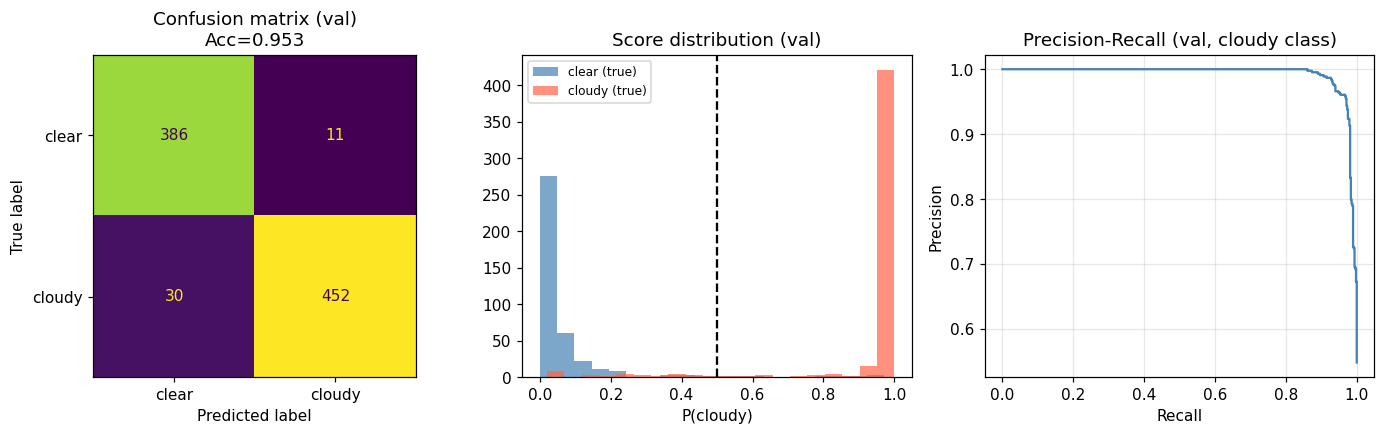

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["clear", "cloudy"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix (val)\nAcc={acc:.3f}")

# Score distribution on val set
axes[1].hist(probs[y_val == 0], bins=20, alpha=0.7, color="steelblue", label="clear (true)")
axes[1].hist(probs[y_val == 1], bins=20, alpha=0.7, color="tomato", label="cloudy (true)")
axes[1].axvline(0.5, color="black", linestyle="--")
axes[1].set_xlabel("P(cloudy)")
axes[1].set_title("Score distribution (val)")
axes[1].legend(fontsize=8)

# Precision-recall curve
prec, rec, thresholds = precision_recall_curve(y_val, probs)
axes[2].plot(rec, prec, color="steelblue")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall (val, cloudy class)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## §5 Compare to cloud_detector_v1

Evaluate the original pre-trained model on the same validation set.

In [16]:
v1_path = REPO_ROOT / "assets/models/cloud_detector_v1.pt"
v1_model, v1_bundle = load_classifier(v1_path, CloudDetection())
v1_model.eval()

with torch.no_grad():
    v1_probs = torch.softmax(v1_model(X_val), dim=1)[:, 1].numpy()
    v1_preds = (v1_probs >= 0.5).astype(int)

v1_acc = (v1_preds == y_val).mean()

print(f"cloud_detector_v1  val accuracy: {v1_acc:.3f}")
print(f"cloud_detector_v2  val accuracy: {acc:.3f}")
print()
print("Note: the val split is NOT from the original training; differences are expected.")
print("The v1 model was trained with possibly different features (64x64 raw-fft)")
print("and a different split (shuffled, not temporal boundary-gap).")

cloud_detector_v1  val accuracy: 0.548
cloud_detector_v2  val accuracy: 0.953

Note: the val split is NOT from the original training; differences are expected.
The v1 model was trained with possibly different features (64x64 raw-fft)
and a different split (shuffled, not temporal boundary-gap).


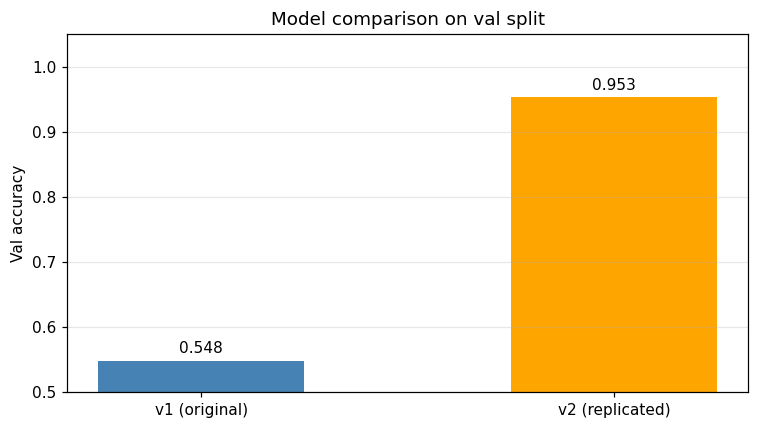

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
bars = ax.bar(x, [v1_acc, acc], color=["steelblue", "orange"], width=0.5)
ax.bar_label(bars, fmt="{:.3f}", padding=3)
ax.set_xticks(x)
ax.set_xticklabels(["v1 (original)", "v2 (replicated)"])
ax.set_ylabel("Val accuracy")
ax.set_ylim(0.5, 1.05)
ax.set_title("Model comparison on val split")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## §6 Stage 2b — Features from the pipeline

Stage 2b replaces the pre-batched `.npy` path with features extracted directly from
L1 Zarr stores produced by the ingest pipeline.  See `03_train_pipeline_features.ipynb`.

**Generating L1 stores (two options):**

```bash
# Option A — Nextflow (production; supports resume / SLURM)
nextflow run . -profile laptop --steps ingest \
    --input samplesheet.csv --outdir ml/cloud-detection/data/

# Option B — pure-Python dev driver (no Nextflow install needed)
pa-run <obs.pffd> ml/cloud-detection/data/ \
    --calib-recipe ml/cloud-detection/recipes/cloud_v1.yml
```

With Option B, every L1 store carries `ds.attrs["calibration"]["resolution"]["source_hash"]`
so you can verify which recipe produced it:

```python
from panoseti_analysis.io.stores import open_store
ds = open_store("ml/cloud-detection/data/L1/obs.dp_img16.module_1.L1.zarr")
ds.pano.validate(level="L1", kind="img")   # contract check
print(ds.attrs["calibration"]["resolution"]["source_hash"])
print(ds.attrs["qc"])                       # QC report
```

**Extracting features and training:**

```bash
pa-features-cloud \
    --stores ml/cloud-detection/data/L1/*.dp_img16.*.zarr \
    --out ml/cloud-detection/cache/ \
    --recipe ml/cloud-detection/recipes/cloud_v1.yml \
    --label-csv <cloud_labels_v2.csv>

pa-train-cloud --launcher attach \
    --feature-cache ml/cloud-detection/cache/features.*.zarr \
    --recipe ml/cloud-detection/recipes/cloud_v1.yml \
    --out ml/cloud-detection/models/
```

**Key challenge for Stage 2b:** Legacy labels are keyed by `feature_uid` (SHA1 hash).
`pa-prep-cloud-labels` converts them to `(module, t_start_ns, t_end_ns, label)` intervals
that `pa-features-cloud` can consume directly (see `03_train_pipeline_features.ipynb`).